
<a href="https://www.zero-grad.com/">
         <img alt="Zero Grad" src="https://i.postimg.cc/vBPDms4J/pythonml-2.png" >
      </a>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Grokking Machine Learning/03- Python Machine Learning/W18/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.drop('CustomerID', axis =1, inplace=True)

**Considering only those two features, we can build our first**

In [5]:
X= df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Scaling

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Clustering using Hierarchical Clustering

## Using the dendrogram to find the optimal number of clusters

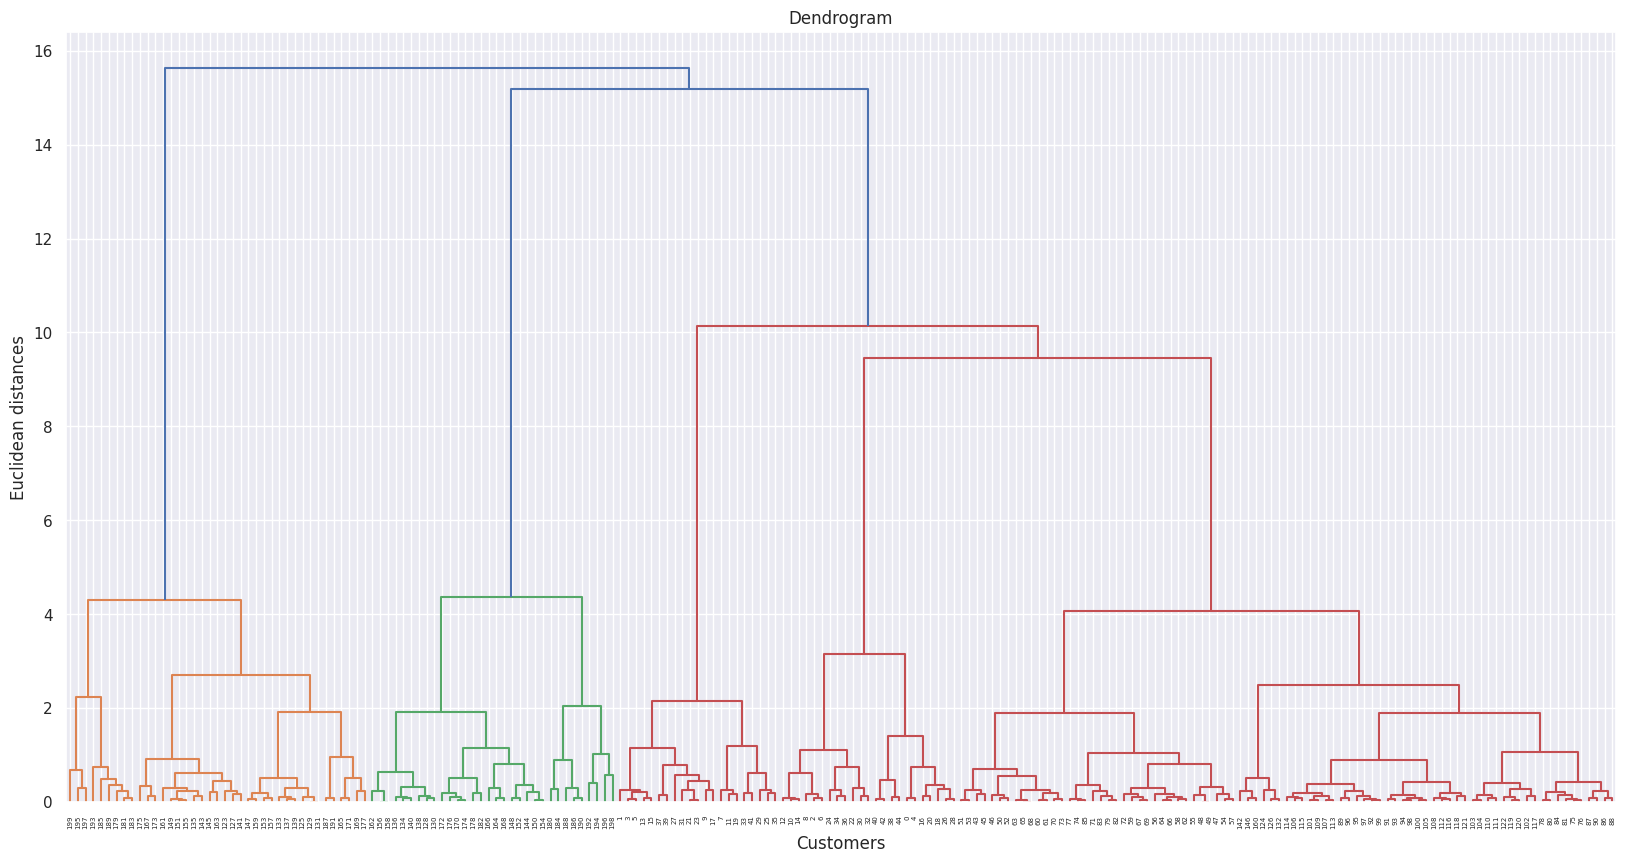

In [7]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(20,10))
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))

plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

### Dendrogram also shows 5 clusters is the optimal No. of Clusters

In [8]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
y_pred = hc.fit_predict(X)

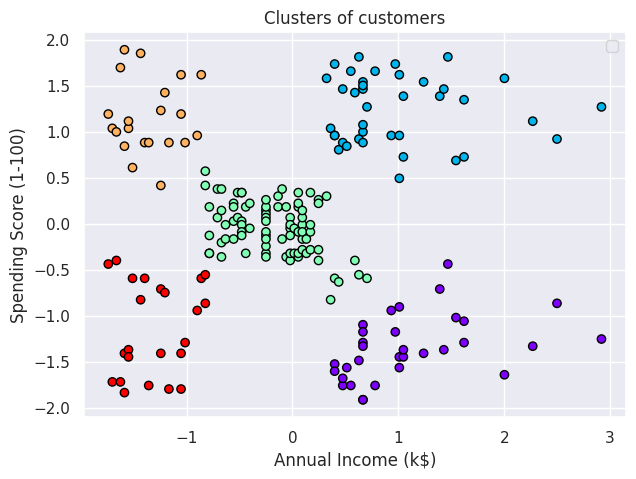

In [9]:
#Visualizing all the clusters
plt.figure(figsize=(7,5))
plt.scatter(x = X[:,0],y = X[:,1],c = y_pred,cmap = 'rainbow',edgecolor = 'black')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

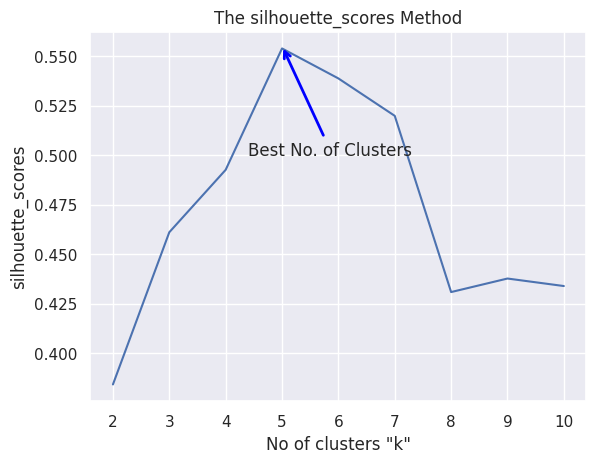

In [11]:
from sklearn.metrics import silhouette_score
silhouette_scores=[]
k_range= range(2,11)

for i in k_range:
    hc = AgglomerativeClustering(n_clusters = i, metric = 'euclidean')
    hc.fit(X)
    silhouette_scores.append(silhouette_score(X, hc.labels_, metric='euclidean'))

# Visualizing the silhouette_scores method to get the optimal value of K
sns.lineplot(x=k_range, y=silhouette_scores)
plt.title('The silhouette_scores Method')
plt.xlabel('No of clusters "k"')
plt.ylabel('silhouette_scores')

# Annotate arrow
plt.annotate('Best No. of Clusters', xy=(5, 0.555), xytext=(4.4, 0.5), xycoords='data',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='blue', lw=2))


plt.show()


# K-means Vs. Agglomerative


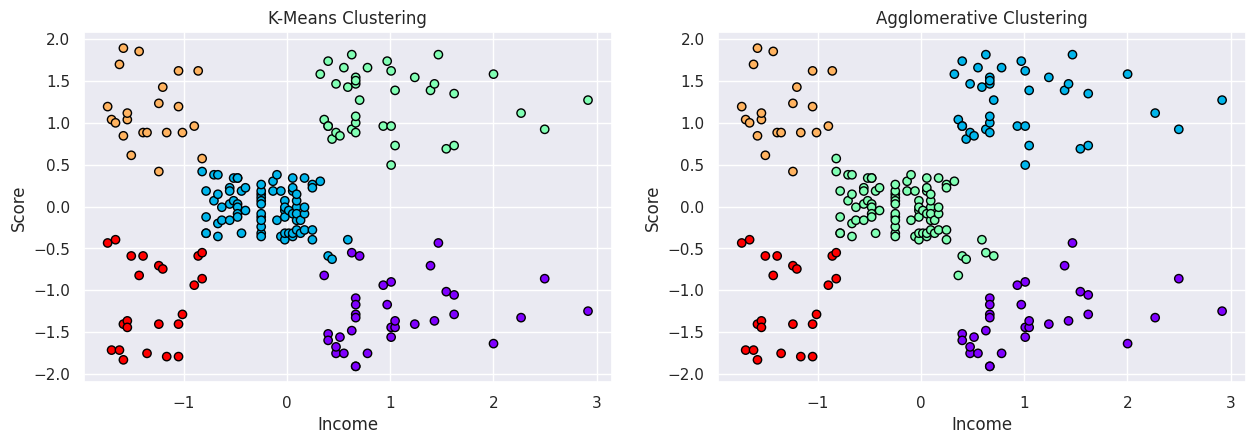

In [10]:
#Kmeans
from sklearn.cluster import KMeans
km5 = KMeans(n_clusters= 5, init='k-means++', n_init ='auto', random_state=0)
y_km = km5.fit_predict(X)


#Agglomerative
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

# Visualizing all the clusters
fig= plt.figure(figsize=(15,10))

fig.add_subplot(221)
plt.scatter(x = X[:,0],y = X[:,1],c = y_km, cmap = 'rainbow',edgecolor = 'black')
plt.title('K-Means Clustering')
plt.xlabel('Income')
plt.ylabel('Score')

fig.add_subplot(222)
plt.scatter(x = X[:,0],y = X[:,1],c = y_hc,cmap = 'rainbow',edgecolor = 'black')
plt.title('Agglomerative Clustering')
plt.xlabel('Income')
plt.ylabel('Score')
plt.show()